In [118]:
from IPython.display import Image, display

# For a local file in the same directory
# For an online image using a URL (uncomment to use)
display(Image(url='https://scikit-learn.org/stable/_images/sphx_glr_plot_map_data_to_normal_001.png', width=300, height=300))



In [119]:
import pandas as pd
import numpy as np

<h3>Standard Scaler</h3>

StandardScaler scales data based on the standard deviation of each feature.

The formula is : 
$$
z = \frac{x - \mu}{\sigma}
$$

- $z$ = Standardized value (Z-score)
- $x$ = Original value
- $\mu$ = Mean
- $\sigma$ = Standard deviation

In [120]:
from sklearn.preprocessing import StandardScaler

# make the dummy data
df = pd.DataFrame({
    'Age':    [18, 25, 32, 40, 50, 60, 70, 80],
    'Height': [150, 160, 165, 170, 175, 180, 185, 190],
    'Weight': [45, 55, 65, 75, 85, 95, 105, 120]
})
df

,Age,Height,Weight
0,18,150,45
1,25,160,55
2,32,165,65
3,40,170,75
4,50,175,85
5,60,180,95
6,70,185,105
7,80,190,120


In [121]:
# import the standard scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-1.40170006, -1.75219161, -1.49022791],
       [-1.06189399, -0.95118973, -1.07191832],
       [-0.72208791, -0.55068879, -0.65360873],
       [-0.33373811, -0.15018785, -0.23529914],
       [ 0.15169914,  0.25031309,  0.18301044],
       [ 0.63713639,  0.65081403,  0.60132003],
       [ 1.12257364,  1.05131497,  1.01962962],
       [ 1.60801089,  1.45181591,  1.647094  ]])

In [122]:
# convert this scaled data into pandas frame
scaled_df = pd.DataFrame(scaled_data,columns=df.columns)
scaled_df

,Age,Height,Weight
0,-1.401700,-1.752192,-1.490228
1,-1.061894,-0.951190,-1.071918
2,-0.722088,-0.550689,-0.653609
3,-0.333738,-0.150188,-0.235299
4,0.151699,0.250313,0.183010
5,0.637136,0.650814,0.601320
6,1.122574,1.051315,1.019630
7,1.608011,1.451816,1.647094


In [123]:
# now inverse the scaled data
inverse_scaled=scaler.inverse_transform(scaled_df)
inverse_scaled

array([[ 18., 150.,  45.],
       [ 25., 160.,  55.],
       [ 32., 165.,  65.],
       [ 40., 170.,  75.],
       [ 50., 175.,  85.],
       [ 60., 180.,  95.],
       [ 70., 185., 105.],
       [ 80., 190., 120.]])

<h3>Min-Max Scaling<h3>

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

- $x$ = Original value
- $x_{\min}$ = Minimum value of the feature
- $x_{\max}$ = Maximum value of the feature
- $x_{\text{scaled}}$ = Scaled value

MinMaxScaler, this normally scales the training data into the range 0 to 1.

In [124]:
# make the dummy data
from sklearn.preprocessing import MinMaxScaler
df = pd.DataFrame({
    'Age':    [18, 25, 32, 40, 50, 60, 70, 80],
    'Height': [150, 160, 165, 170, 175, 180, 185, 190],
    'Weight': [45, 55, 65, 75, 85, 95, 105, 120]
})
df

,Age,Height,Weight
0,18,150,45
1,25,160,55
2,32,165,65
3,40,170,75
4,50,175,85
5,60,180,95
6,70,185,105
7,80,190,120


In [125]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df

,Age,Height,Weight
0,0.000000,0.000,0.000000
1,0.112903,0.250,0.133333
2,0.225806,0.375,0.266667
3,0.354839,0.500,0.400000
4,0.516129,0.625,0.533333
5,0.677419,0.750,0.666667
6,0.838710,0.875,0.800000
7,1.000000,1.000,1.000000


In [126]:
# now inverse the scaled data
inverse_scaled=scaler.inverse_transform(scaled_df)
inverse_scaled

array([[ 18., 150.,  45.],
       [ 25., 160.,  55.],
       [ 32., 165.,  65.],
       [ 40., 170.,  75.],
       [ 50., 175.,  85.],
       [ 60., 180.,  95.],
       [ 70., 185., 105.],
       [ 80., 190., 120.]])

<h3>Max Abs Scaler</h3>

MaxAbsScaler is another scaling technique in scikit-learn. It scales each feature by dividing every value by the largest absolute value in that feature/column

The formula is:
$X_{\text{scaled}} = \frac{X}{|X|_{\max}}$

In [127]:
import pandas as pd

df = pd.DataFrame({
    'Feature_A': [-100, -50, 0, 50, 100],
    'Feature_B': [-20, -10, 0, 10, 20],
    'Feature_C': [-500, -250, 0, 100, 250]
})

print(df)

   Feature_A  Feature_B  Feature_C
0       -100        -20       -500
1        -50        -10       -250
2          0          0          0
3         50         10        100
4        100         20        250


In [128]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

scaled_data = scaler.fit_transform(df)
scaled_data

array([[-1. , -1. , -1. ],
       [-0.5, -0.5, -0.5],
       [ 0. ,  0. ,  0. ],
       [ 0.5,  0.5,  0.2],
       [ 1. ,  1. ,  0.5]])

In [129]:
# now inverse the scaled data
inverse_scaled=scaler.inverse_transform(scaled_data)
inverse_scaled
df_scaled = pd.DataFrame(
    inverse_scaled,
    columns=df.columns
)
df_scaled

,Feature_A,Feature_B,Feature_C
0,-100.0,-20.0,-500.0
1,-50.0,-10.0,-250.0
2,0.0,0.0,0.0
3,50.0,10.0,100.0
4,100.0,20.0,250.0


<h3>Robust Scaler</h3>

**RobustScaler** is a data scaling technique that is useful when the dataset contains **outliers**.

### How it works

It uses:

- **Median** instead of Mean
- **IQR** instead of Standard Deviation

The formula is:

$$
\text{Scaled Value} = \frac{x-\text{Median}}{Q_3-Q_1}
$$

where:

- $x$ = original value
- $Q_1$ = 25th percentile
- $Q_3$ = 75th percentile
- $IQR = Q_3-Q_1$

### Why use RobustScaler?

**Mean and standard deviation are sensitive to outliers**, while **median and IQR are less affected by outliers**.

Example:

10, 20, 30, 40, 50, 1000

Here, **1000** is an outlier.

`1000` can strongly affect the **mean and standard deviation**, but has much less effect on the **median and IQR**.

### When to use

> **Use RobustScaler when your numerical features contain significant outliers and you want scaling that is less affected by them.**

**Remember:** RobustScaler **does not remove outliers**. It only reduces their influence on the scaling calculation.

RobustScaler: Use when your dataset contains significant outliers that you cannot or should not remove (such as financial or real-world messy data).</br>
StandardScaler: Use when data is normally distributed and has few or no outliers.</br>
MinMaxScaler: Use when you need all feature values confined to a strict, fixed range like \([0, 1]\), and outliers are absent.

<h3> Data Transformation Non Linear to Guassian / Normal Data Distribution </h3>

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
np.random.seed(0)
data = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(data, columns=['values'])
df.head(5)

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='values', ylabel='Count'>

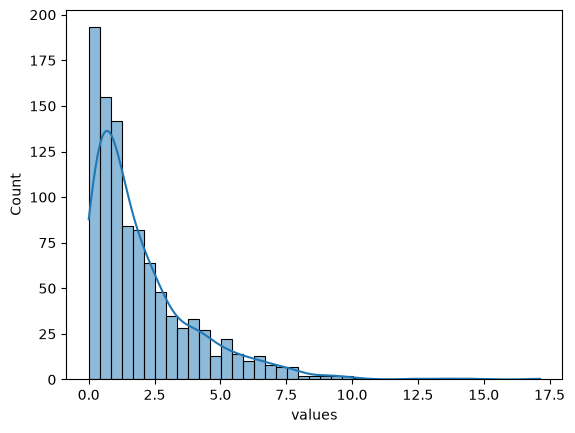

In [10]:
sns.histplot(df['values'], kde=True)

This is the right skewed distribution, now convert it to normal distribution

In [ ]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeojohson = PowerTransformer(method='yeo-johnson', standardize=False)
pt_quantile = QuantileTransformer(output_distribution='normal')

# for box data value must be positive
df['box-cox'] = pt_boxcox.fit_transform(df[['values']] + 1)
df['box-cox'] = pt_yeojohson.fit_transform(df[['values']] + 1)
df['box-cox'] = pt_quantile.fit_transform(df[['values']] + 1)


<Axes: xlabel='box-cox', ylabel='Count'>

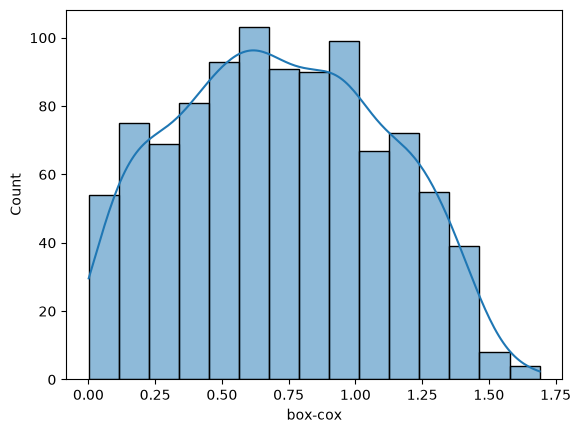

In [14]:
sns.histplot(df['box-cox'], kde=True)